<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Breast-Cancer-Wisconsin-(Diagnostic)-Data-Set" data-toc-modified-id="Breast-Cancer-Wisconsin-(Diagnostic)-Data-Set-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Breast Cancer Wisconsin (Diagnostic) Data Set</a></span><ul class="toc-item"><li><span><a href="#Attribute-Information:" data-toc-modified-id="Attribute-Information:-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Attribute Information:</a></span></li><li><span><a href="#分類器" data-toc-modified-id="分類器-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>分類器</a></span></li><li><span><a href="#仮説クラス" data-toc-modified-id="仮説クラス-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>仮説クラス</a></span></li><li><span><a href="#課題の見通し" data-toc-modified-id="課題の見通し-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>課題の見通し</a></span></li></ul></li><li><span><a href="#shapeと行列積" data-toc-modified-id="shapeと行列積-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>shapeと行列積</a></span></li><li><span><a href="#最小二乗損失" data-toc-modified-id="最小二乗損失-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>最小二乗損失</a></span><ul class="toc-item"><li><span><a href="#確認問題" data-toc-modified-id="確認問題-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>確認問題</a></span></li></ul></li><li><span><a href="#勾配と勾配降下法" data-toc-modified-id="勾配と勾配降下法-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>勾配と勾配降下法</a></span><ul class="toc-item"><li><span><a href="#最急降下法の3D模式図" data-toc-modified-id="最急降下法の3D模式図-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>最急降下法の3D模式図</a></span></li><li><span><a href="#学習率を変えると何が起きるか" data-toc-modified-id="学習率を変えると何が起きるか-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>学習率を変えると何が起きるか</a></span></li></ul></li><li><span><a href="#QR分解と最小二乗解" data-toc-modified-id="QR分解と最小二乗解-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>QR分解と最小二乗解</a></span><ul class="toc-item"><li><span><a href="#デモの見方" data-toc-modified-id="デモの見方-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>デモの見方</a></span></li></ul></li><li><span><a href="#分類結果の評価" data-toc-modified-id="分類結果の評価-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>分類結果の評価</a></span><ul class="toc-item"><li><span><a href="#表示用関数" data-toc-modified-id="表示用関数-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>表示用関数</a></span></li></ul></li><li><span><a href="#課題に取り組む前のチェックリスト" data-toc-modified-id="課題に取り組む前のチェックリスト-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>課題に取り組む前のチェックリスト</a></span></li></ul></div>

# Breast Cancer Wisconsin (Diagnostic) Data Set

<https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)>

## Attribute Information:

1. ID number 
1. Diagnosis (M = malignant:1, B = benign:-1) M:悪性，B:良性
2. 3-32

    * M:悪性(-1)，B:良性(1) => M:悪性(1)，B:良性(-1)
    * cancer detectorの評価なので，positiveは悪性であるべき．

Ten real-valued features are computed for each cell nucleus: 

* 半径radius (mean of distances from center to points on the perimeter) 
* テクスチャtexture (standard deviation of gray-scale values) 
* 境界の長さperimeter 
* 面積area 
* なめらかさsmoothness (local variation in radius lengths) 
* コンパクトさcompactness (perimeter^2 / area - 1.0) 
* くぼみ度合いconcavity (severity of concave portions of the contour) 
* くぼみの数concave points (number of concave portions of the contour) 
* 対称性symmetry 
* フラクタル次元fractal dimension ("coastline approximation" - 1)

のそれぞれのmean, stderr, worst数値を保持している．

http://people.idsia.ch/~juergen/deeplearningwinsMICCAIgrandchallenge.html

## 分類器
用意された訓練(training)データには，
$\boldsymbol{A}$に上に記した特徴量が，
$\boldsymbol{b}$に悪性(1, positive)か良性(-1, negative)かを
示す数値が入っている．

与えられた特徴ベクトル$\boldsymbol{y}$に対し，
細胞組織が悪性か良性かを分類する関数$C(\boldsymbol{y})$を選び出すプログラムを作成しよう．

## 仮説クラス
分類器は可能な分類器の集合(**仮説クラス**)から選ばれる．この場合，仮説クラスとは特徴ベクトルの空間$\mathbb{R}^D$から$\mathbb{R}$への線形関数$h(\cdot)$である．すると分類器は次のような関数として定義される．

$$
C(\boldsymbol{y}) = 
\left\{ \begin{array}{ccc}
+1 &  {\rm when} & h(\boldsymbol{y})\geq 0\\
-1 &  {\rm when} & h(\boldsymbol{y})<0
\end{array} \right.
$$

各線形関数$h:\mathbb{R}^D \rightarrow \mathbb{R}$に対して，
次のような$D$ベクトル$\boldsymbol{w}$が存在する．
$$
h(\boldsymbol{y}) = \boldsymbol{w}\cdot \boldsymbol{y}
$$
したがって，そのような線形関数を選ぶことは，結局$D$ベクトル$\boldsymbol{w}$を
選ぶことに等しい．特に，$\boldsymbol{w}$を選ぶことは，仮説クラス$h$を
選ぶことと等価なので，$\boldsymbol{w}$を**仮説ベクトル**と呼ぶ．

問題を単純化すると，分類器を単なるベクトルとみなして，データとの掛け算で予測がつきます．本来は予測を-1,1とかに投影しないといけないんですが，単純化のためにそのままの値を用います．問題はどうやってこの仮説ベクトル$\boldsymbol{w}$の各要素の値を決定するか？ですよね．


## 課題の見通し

この仮説ベクトルの求め方として，勾配法と，QR分解から得られる最小二乗解を示す．最終的に本課題で得られる仮説ベクトルは，`print_w(w_qr)`によって次のように表示される．

| feature | mean | StdErr | worst |
|:---|---:|---:|---:|
| radius | -0.869922 | 0.956592 | 0.408606 |
| texture | 0.024314 | 0.082053 | 0.003346 |
| perimeter | 0.062680 | 0.007943 | 0.000678 |
| area | 0.003275 | -0.004977 | -0.002511 |
| smoothness | 8.790305 | 27.841938 | -4.531369 |
| compactness | -1.747148 | -3.301519 | -0.590111 |
| concavity | 0.202848 | -4.985957 | 0.719369 |
| concave_pts | 6.506449 | 16.318887 | 2.158967 |
| symmetry | -5.061760 | -10.316290 | 3.803467 |
| fractal_dim | -49.167545 | 21.332168 | 12.298425 |

さらに，この仮説ベクトルを検証データへ適用して`show_accuracy2(x_valid, y_valid, w_qr)`を実行すると，次の混同行列が得られる．positiveは悪性（$+1$），negativeは良性（$-1$）である．

| actual＼predicted | malignant（+1） | benign（-1） |
|:---|---:|---:|
| malignant（+1） | 64 | 2 |
| benign（-1） | 6 | 197 |

accuracyは$261/269=97.026\%$である．この結果を得るために必要となる考え方と計算手順を，以下に記述する．

# shapeと行列積

本番データを使う前に，4個のデータを直線で近似する例を，以降のデモで一貫して用いる．$A$の各行は$[1,x]$，$b$は実際の値である．列ベクトルを`(d, 1)`で統一すると，意図しないbroadcastingを避けやすい．

In [1]:
import numpy as np

A = np.array([
    [1.0, 0.0],
    [1.0, 1.0],
    [1.0, 2.0],
    [1.0, 3.0],
])
b = np.array([[1.0], [2.0], [2.0], [4.0]])
w0_demo = np.array([[0.2], [0.4]])
predicted_b0 = A @ w0_demo

print("A:", A.shape)
print("b:", b.shape)
print("w0_demo:", w0_demo.shape)
print("A @ w0_demo:", predicted_b0.shape)
print(predicted_b0)

A: (4, 2)
b: (4, 1)
w0_demo: (2, 1)
A @ w0_demo: (4, 1)
[[0.2]
 [0.6]
 [1. ]
 [1.4]]


`(n,)`と`(n, 1)`を引くと，NumPyはbroadcastingによって`(n, n)`を作る場合がある．課題ではラベルと予測をともに列ベクトルにそろえ，各段階でshapeを確認すること．

# 最小二乗損失

残差$r=Aw-b$を用い，損失を

$$
J(w)=\frac{1}{2}\lVert Aw-b\rVert_2^2
=\frac{1}{2}\sum_{i=1}^{n}(A_iw-b_i)^2
$$

と定義する．係数$1/2$は微分後の式を簡潔にするためである．分類の正解数を直接数える代わりに，連続値であるスコアと正解ラベルのずれを測っている．したがって，損失が小さくなれば一般に良い方向だが，accuracyが必ず同じ割合で改善するとは限らない．

In [2]:
residual_demo = A @ w0_demo - b
loss_demo = 0.5 * np.linalg.norm(residual_demo) ** 2
print("residual =\n", residual_demo)
print("loss =", loss_demo)

residual =
 [[-0.8]
 [-1.4]
 [-1. ]
 [-2.6]]
loss = 5.179999999999999


## 確認問題

1．`A @ w0_demo`のshapeを，行列積の規則だけから説明せよ．  
2．`b.flatten()`を使って残差を作ると，どのshapeになるか予想してから確かめよ．  
3．損失が0なら，すべての分類が正しいと言えるか．逆は言えるか．

# 勾配と勾配降下法

$w_j$について偏微分すると，

$$
\frac{\partial J}{\partial w_j}
=\sum_{i=1}^{n}(A_iw-b_i)A_{ij}
$$

である．すべての成分をまとめると，

$$
\nabla J(w)=A^\mathsf{T}(Aw-b)
$$

となる．$A^\mathsf{T}$のshapeは$(d,n)$，残差のshapeは$(n,1)$なので，勾配は$w$と同じ$(d,1)$になる．

勾配降下法は，学習率$\eta>0$を用いて

$$
w\leftarrow w-\eta\nabla J(w)
$$

を繰り返す．実装時には「スコア→残差→勾配→更新」の4段階を分け，各shapeを確認するとよい．

In [3]:
# 小さな例における1回分の更新である．課題では式を見て自分でループを組み立てること．
eta_demo = 0.05
gradient_demo = A.T @ (A @ w0_demo - b)
w1_demo = w0_demo - eta_demo * gradient_demo

print("gradient shape:", gradient_demo.shape)
print("loss before:", 0.5 * np.linalg.norm(A @ w0_demo - b) ** 2)
print("loss after :", 0.5 * np.linalg.norm(A @ w1_demo - b) ** 2)

gradient shape: (2, 1)
loss before: 5.179999999999999
loss after : 0.5638


## 最急降下法の3D模式図

Pythonの基本的な作図ライブラリであるMatplotlibを使う．Jupyter上で図を回転・拡大できるようにするには，Matplotlibの対話バックエンド`ipympl`が必要である．未導入の場合は，Notebookとは別のターミナルで次のいずれかを実行し，カーネルを再起動する．

```bash
python -m pip install ipympl
```

```bash
conda install -c conda-forge ipympl
```

Plotly，Bokeh，Altairなども対話的な作図の候補だが，ここでは2次元の図と同じMatplotlibに統一する．`ipympl`を利用できる場合，`%matplotlib widget`に相当する設定を行う．利用できない場合も静止画として表示する．

横軸を$w_0,w_1$，高さを損失$J(w)$とする．赤い点は`w0_demo`から始まる最急降下法の更新軌跡である．対話表示では，グラフをドラッグすると回転でき，ホイールで拡大・縮小できる．

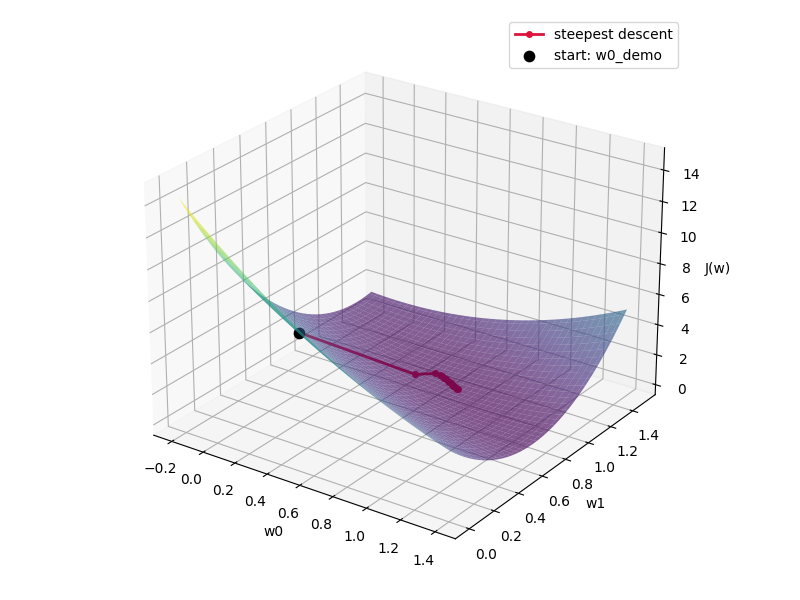

In [4]:
import importlib.util

# ipymplがあれば，%matplotlib widgetに相当する設定を行う．
if importlib.util.find_spec("ipympl") is not None:
    get_ipython().run_line_magic("matplotlib", "widget")
else:
    get_ipython().run_line_magic("matplotlib", "inline")
    print("対話操作を有効にするには，python -m pip install ipympl を実行する．")

import matplotlib.pyplot as plt

# 同じA，bから損失面J(w0, w1)を作る．
w0_axis = np.linspace(-0.2, 1.4, 80)
w1_axis = np.linspace(0.0, 1.5, 80)
W0, W1 = np.meshgrid(w0_axis, w1_axis)
loss_surface = np.zeros_like(W0)

for row, target in zip(A, b[:, 0]):
    prediction = row[0] * W0 + row[1] * W1
    loss_surface += 0.5 * (prediction - target) ** 2

# w0_demoから15回更新した軌跡を保存する．
w_current = w0_demo.copy()
w_path = [w_current[:, 0].copy()]
loss_path = [0.5 * np.linalg.norm(A @ w_current - b) ** 2]

for _ in range(15):
    gradient = A.T @ (A @ w_current - b)
    w_current = w_current - eta_demo * gradient
    w_path.append(w_current[:, 0].copy())
    loss_path.append(0.5 * np.linalg.norm(A @ w_current - b) ** 2)

w_path = np.asarray(w_path)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W0, W1, loss_surface, cmap="viridis", alpha=0.65)
ax.plot(
    w_path[:, 0], w_path[:, 1], loss_path,
    color="crimson", marker="o", markersize=4,
    linewidth=2, label="steepest descent",
)
ax.scatter(
    w_path[0, 0], w_path[0, 1], loss_path[0],
    color="black", s=55, label="start: w0_demo",
)
ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.set_zlabel("J(w)")
ax.view_init(elev=25, azim=-55)
ax.legend()
plt.tight_layout()
plt.show()

## 学習率を変えると何が起きるか

- 小さすぎる：損失は安定して減るが，収束が遅い．
- 適切：損失が速やかに減る．
- 大きすぎる：最小値を飛び越し，振動または発散する．

課題では初期損失，最終損失，途中の損失を保存し，「計算した」だけでなく「下がった」ことも検証する．

# QR分解と最小二乗解

$n\ge d$で列が一次独立な行列$A$を，reduced QR分解

$$
A=QR
$$

で表す．このとき$Q$は$(n,d)$，$R$は$(d,d)$である．最小二乗解は

$$
Rw=Q^\mathsf{T}b
$$

という連立方程式を解いて得られる．`np.linalg.solve`の第1引数には係数行列$R$を，第2引数には右辺$Q^\mathsf{T}b$を渡す．したがって，逆行列を明示的に作らず，次のように直接書ける．

```python
w = np.linalg.solve(R, Q.T @ b)
```

Q.T @ b =
 [[-4.5       ]
 [-2.01246118]]
w =
 [[0.9]
 [0.9]]

       b  predicted b
   1.000        0.900
   2.000        1.800
   2.000        2.700
   4.000        3.600


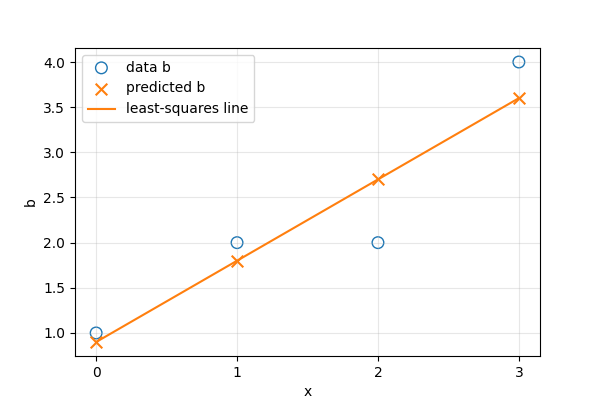

In [5]:
# shape，損失，勾配のデモと同じA，bを使う．
Q, R = np.linalg.qr(A, mode="reduced")
print("Q.T @ b =\n", Q.T @ b)

w = np.linalg.solve(R, Q.T @ b)
predicted_b = A @ w

print("w =\n", w)
print("\n       b  predicted b")
for actual, predicted in zip(b[:, 0], predicted_b[:, 0]):
    print(f"{actual:8.3f}{predicted:13.3f}")

import matplotlib.pyplot as plt

x = A[:, 1]
plt.figure(figsize=(6, 4))
plt.scatter(x, b[:, 0], s=70, facecolors="none", edgecolors="tab:blue", label="data b")
plt.scatter(x, predicted_b[:, 0], s=70, marker="x", color="tab:orange", label="predicted b")
plt.plot(x, predicted_b[:, 0], color="tab:orange", label="least-squares line")
plt.xlabel("x")
plt.ylabel("b")
plt.xticks(x)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## デモの見方

青い丸が実際のデータ点`b`，橙色の×が`predicted_b = A @ w`による予測点，橙色の線が最小二乗直線である．

`np.linalg.solve(R, Q.T @ b)`から$w=[0.9,0.9]^\mathsf{T}$が得られ，直線は$\widehat b=0.9+0.9x$となる．直線はすべての青い点を通らないが，縦方向の差$b-Aw$の二乗和を最小にしている．

乳がんデータでは，$A$，$b$，$w$がそれぞれ`x_train`，`y_train`，`w_qr`に対応する．予測値`x_train @ w_qr`は連続値であり，その符号で悪性または良性へ分類する．

# 分類結果の評価

悪性をpositive，良性をnegativeとする．

| 正解＼予測 | 悪性（positive） | 良性（negative） |
|---|---:|---:|
| 悪性（positive） | TP：正しく検出 | FN：見落とし |
| 良性（negative） | FP：再検査につながる誤警告 | TN：正しく除外 |

$$
\mathrm{accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
$$

医療の文脈では，同じ誤りでもFNとFPの意味が異なる．したがって，accuracyだけを報告せず，混同行列も示す．実装の擬似コードは次のとおりである．

```text
scoresを計算する
scoresの符号から予測ラベルを作る
正解ラベルと予測ラベルの条件を組み合わせてTP，TN，FP，FNを数える
4項目の合計が標本数と一致することを確認する
```

## 表示用関数

課題では，次の3関数を準備済みのものとして使える．`print_w`は，データ列の並びが「mean 10列，StdErr 10列，worst 10列」であることに注意して係数を表示する．`show_accuracy`は要約，`show_accuracy2`は混同行列を表示する．

In [6]:
FEATURE_NAMES = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_pts", "symmetry", "fractal_dim",
]


def print_w(w):
    """30次元の係数を，特徴量ごとにmean，StdErr，worstの順で表示する．"""
    values = np.asarray(w, dtype=float).reshape(-1)
    if values.size != 30:
        raise ValueError("w must contain 30 elements")

    print(f'{"feature":<14}{"mean":>13}{"StdErr":>13}{"worst":>13}')
    print("-" * 53)
    for i, name in enumerate(FEATURE_NAMES):
        print(f"{name:<14}{values[i]:13.6f}{values[i + 10]:13.6f}{values[i + 20]:13.6f}")


def _classification_counts(mA, vb, vw):
    actual = np.asarray(vb).reshape(-1)
    scores = (np.asarray(mA) @ np.asarray(vw)).reshape(-1)
    predicted = np.where(scores >= 0, 1, -1)

    tp = int(np.sum((actual == 1) & (predicted == 1)))
    tn = int(np.sum((actual == -1) & (predicted == -1)))
    fp = int(np.sum((actual == -1) & (predicted == 1)))
    fn = int(np.sum((actual == 1) & (predicted == -1)))
    total = actual.size
    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "correct": tp + tn,
        "total": total,
        "accuracy": (tp + tn) / total,
    }


def show_accuracy(mA, vb, vw):
    """正解数，accuracy，偽陽性，偽陰性を簡潔に表示する．"""
    result = _classification_counts(mA, vb, vw)
    print(f"correct       : {result['correct']:4d} / {result['total']:4d}")
    print(f"accuracy      : {result['accuracy']:8.3%}")
    print(f"false positive: {result['fp']:4d}  (良性を悪性と予測)")
    print(f"false negative: {result['fn']:4d}  (悪性を良性と予測)")
    return result


def show_accuracy2(mA, vb, vw):
    """混同行列を表示する．positiveは悪性（+1）である．"""
    result = _classification_counts(mA, vb, vw)
    print(" " * 22 + "predicted")
    print(f'{"":22}{"malignant(+1)":>15}{"benign(-1)":>13}')
    print(f'{"actual malignant(+1)":22}{result["tp"]:15d}{result["fn"]:13d}')
    print(f'{"actual benign(-1)":22}{result["fp"]:15d}{result["tn"]:13d}')
    print(f"accuracy: {result['accuracy']:.3%}")
    return result

# 課題に取り組む前のチェックリスト

- [ ] `A.shape == (n, d)`，`b.shape == (n, 1)`，`w.shape == (d, 1)`を説明できる．
- [ ] `*`（要素ごとの積）と`@`（行列積）を区別できる．
- [ ] 損失とaccuracyが異なる量であることを説明できる．
- [ ] 勾配のshapeが`w`と同じになる理由を説明できる．
- [ ] reduced QR分解における$Q$と$R$のshapeを説明できる．
- [ ] FNとFPの違いを説明できる．

課題では，この資料の小さな例をそのまま貼り付けるのではなく，乳がんデータの変数，shape，目的に合わせて実装すること．